In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
"""ENSG00000205846""","""aspartate_aminotransferase_int""",0.049103,0.298817,0.298817,1.0
…,…,…,…,…,…
"""ENSG00000104408""","""mean_corpuscular_volume_int""",0.003124,-0.005248,0.005248,-1.0
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0


In [3]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1


In [4]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/annotations_fillna_ukbgym.parquet -o /home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet

anno = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

min_range = -2000
max_range = +0

anno = (
    anno
    .filter(
        # Choose Gene Body
        ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)) &

        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Custom variant class filter
        # (pl.col('relative_cds_position')>=0.5) &

        # Choose regulatory region
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &
        
        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region']).union(set(existing_annos))
    )
)

anno.head().collect()

[===========================================================>] Completed 7,200,691,704 of 7,200,691,704 bytes (100%) /home/dnanexus/data_dir/annotations_fillna_ukbgym.parquett================================>                           ] Downloaded 4,009,754,624 of 7,200,691,704 bytes (55%) /home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet


absplice2_max,consequence_splice_acceptor_variant,verphylop,five_prime_utr_variant_consequence_ustop_lost,esmscoremissense,encode_dels,consequence_frameshift_variant,five_prime_utr_variant_consequence_ustop_gained,encode_pls,promoterai,region,five_prime_utr_variant_consequence_uaug_gained,low_complexity_domain,loftee_hc,ted_domain,loftee_lc,id,abexp_abs_max,pangolin_score,consequence_synonymous_variant,encode_pels,gpn_score,am_pathogenicity,encode_tf,mobi_curated_disorder_priority,consequence_missense_variant,consequence_splice_donor_variant,consequence_stop_gained,relative_cds_position,delta_score,cadd_raw,mobi_lip_full,consequence_stop_lost,five_prime_utr_variant_consequence_uaug_lost,consequence_start_lost
f32,i8,f32,u8,f32,bool,i8,u8,bool,f32,str,u8,bool,i8,bool,i8,str,f32,f32,i8,bool,f32,f32,bool,bool,i8,i8,i8,f32,f32,f32,bool,i8,u8,i8
0.002202,0,10.541,0,-6.18,false,0,0,false,0.0,"""ENSG00000104112""",0,false,0,true,0,"""chr15:51688397:G:A""",0.145382,0.01,0,false,-6.13,0.6793,false,false,1,0,0,0.38,0.0,5.221107,true,0,0,0
0.009521,0,4.069,0,-4.235,false,0,0,false,0.0,"""ENSG00000116127""",0,false,0,false,0,"""chr2:73455162:C:G""",0.067689,0.0,0,false,-8.47,0.3752,false,false,1,0,0,0.6,0.0,4.401463,false,0,0,0
0.002284,0,7.063,0,-1.937,false,0,0,false,0.0,"""ENSG00000137076""",0,false,0,true,0,"""chr9:35711346:T:A""",0.085274,0.08,0,false,-8.78,0.1793,false,false,1,0,0,0.52,0.14,3.622959,true,0,0,0
0.000481,0,4.639,0,-5.376,false,0,0,false,0.0,"""ENSG00000250722""",0,false,0,false,0,"""chr5:42808215:C:T""",0.110739,0.0,0,true,-5.86,0.0,false,false,1,0,0,0.12,0.0,4.110966,false,0,0,0
0.000033,0,-0.082,0,-4.004,false,0,0,false,0.0,"""ENSG00000167791""",0,false,0,false,0,"""chr11:67522634:G:A""",0.0,0.0,0,true,-0.09,0.0648,false,false,1,0,0,0.19,0.0,0.508567,false,0,0,0


In [5]:
# Add Olink measurements
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"
OLINK_APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{OLINK_APPV_FILE} -o {LOCAL_APPV_DIR}/{OLINK_APPV_FILE} -f

olink_appv = (
    pl.scan_parquet(f"{LOCAL_APPV_DIR}/{OLINK_APPV_FILE}")
    .filter(pl.col('n_individuals') <= mac)
    .rename({
        'mean_pheno_value': 'olink_mean_pheno',
    })
    .with_columns(
        olink_mean_pheno_abs = pl.col('olink_mean_pheno').abs(),
        region = pl.col('phenotype').str.replace(r'_olink', '')
    )
    .filter(
        pl.col('region').is_in(gene_trait_df.select('region').unique().to_series())
    )
    .select(['id', 'region', 'olink_mean_pheno', 'olink_mean_pheno_abs'])
)

anno = (
    anno.lazy()
    .join(
        olink_appv,
        on=['id', 'region'],
        how='inner'       # only keep variants with Olink measurements
    )
    .collect(engine='streaming')
)

anno

[===========================================================>] Completed 100,324,032 of 100,324,032 bytes (100%) /home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquetet


/tmp/ipykernel_844243/2142176598.py:31: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


absplice2_max,consequence_splice_acceptor_variant,verphylop,five_prime_utr_variant_consequence_ustop_lost,esmscoremissense,encode_dels,consequence_frameshift_variant,five_prime_utr_variant_consequence_ustop_gained,encode_pls,promoterai,region,five_prime_utr_variant_consequence_uaug_gained,low_complexity_domain,loftee_hc,ted_domain,loftee_lc,id,abexp_abs_max,pangolin_score,consequence_synonymous_variant,encode_pels,gpn_score,am_pathogenicity,encode_tf,mobi_curated_disorder_priority,consequence_missense_variant,consequence_splice_donor_variant,consequence_stop_gained,relative_cds_position,delta_score,cadd_raw,mobi_lip_full,consequence_stop_lost,five_prime_utr_variant_consequence_uaug_lost,consequence_start_lost,olink_mean_pheno,olink_mean_pheno_abs
f32,i8,f32,u8,f32,bool,i8,u8,bool,f32,str,u8,bool,i8,bool,i8,str,f32,f32,i8,bool,f32,f32,bool,bool,i8,i8,i8,f32,f32,f32,bool,i8,u8,i8,f32,f32
0.002406,0,1.503,0,-11.069,false,0,0,false,0.0,"""ENSG00000167601""",0,false,0,true,0,"""chr19:41252369:C:T""",0.366974,0.01,0,false,-9.11,0.2113,false,false,1,0,0,0.64,0.0,4.757945,false,0,0,0,-0.467565,0.467565
0.000371,0,0.289,0,-5.47,false,0,0,true,0.0456,"""ENSG00000025708""",0,false,0,true,0,"""chr22:50525883:C:T""",0.042054,0.0,0,false,-3.62,0.1026,false,false,1,0,0,0.92,0.0,1.793782,false,0,0,0,-1.638057,1.638057
0.002666,0,0.68,0,-4.052,false,0,0,false,-0.0136,"""ENSG00000141505""",0,false,0,false,0,"""chr17:7176896:T:G""",0.15996,0.01,0,false,-3.45,0.0826,false,false,1,0,0,0.33,0.0,2.401778,true,0,0,0,-0.028763,0.028763
0.000321,0,0.207,0,-5.671,false,0,0,false,0.0,"""ENSG00000099331""",0,false,0,false,0,"""chr19:17198260:C:T""",0.139159,0.0,0,false,-1.36,0.1059,false,false,1,0,0,0.65,0.0,1.679595,false,0,0,0,1.209404,1.209404
0.002655,0,1.532,0,-3.222,false,0,0,false,0.0,"""ENSG00000008710""",0,false,0,false,0,"""chr16:2102389:C:G""",0.016225,0.01,0,false,-2.4,0.1113,false,false,1,0,0,0.71,0.0,0.354748,false,0,0,0,0.008867,0.008867
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.000296,0,8.841,0,-8.579,false,0,0,false,0.0,"""ENSG00000155657""",0,false,0,false,0,"""chr2:178779267:T:G""",0.12721,0.0,0,false,-11.86,0.8143,false,false,1,0,0,0.04,0.0,3.823756,false,0,0,0,1.973491,1.973491
0.000201,0,5.42,0,-11.466,false,0,0,false,0.0,"""ENSG00000155657""",0,false,0,false,0,"""chr2:178723115:C:T""",0.083404,0.0,0,true,-8.08,0.0,false,false,1,0,0,0.2,0.0,3.49038,false,0,0,0,0.123089,0.123089
0.000033,0,6.854,0,-4.211,false,0,0,false,0.0,"""ENSG00000155657""",0,false,0,false,0,"""chr2:178575129:T:C""",0.015385,0.0,0,true,-7.15,0.0,false,false,1,0,0,0.66,0.0,2.616912,false,0,0,0,0.729691,0.729691


In [6]:
exp_annos = pl.DataFrame({
    "category": ["olink", "olink"],
    "annotation": ["olink_mean_pheno", "olink_mean_pheno_abs"],
    "color": ["gray", "gray"],
    "label": ["Plasma Olink", "Plasma Olink (abs)"],
    "annotation_dir": [-1, 1],
}).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

anno_config_df = pl.concat([anno_config_df, exp_annos], how='vertical')
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1
"""vep_consequences""","""consequence_synonymous_variant""","""#C6DBEF""","""VEP Synonymous""",1
"""naive""","""relative_cds_position""","""#b5de2b""","""Relative CDS Position""",-1


In [7]:
# # Load fillna annotations
# anno_fillna = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")
# fillna_cols = set([c+'_is_na' for c in existing_annos]).intersection(set(anno_fillna.collect_schema().names()))

# anno_fillna_melted = (
#     anno_fillna
#     .select(['id', 'region'] + list(fillna_cols))
#     .join(
#         anno.select(['id', 'region']).lazy(), 
#         on=['id', 'region'], 
#         how='semi'
#     )
#     .unpivot(
#         index=["id", "region"],
#         on=list(fillna_cols),
#         variable_name="annotation",
#         value_name="annotation_is_na"
#     )
#     .filter(
#         pl.col('annotation_is_na') == False
#     )
#     .with_columns(
#         annotation = pl.col('annotation').str.replace('_is_na$', '')
#     )
#     # .collect(engine='streaming')
# )


# selected_categories = ['olink', 'missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # CDS
selected_categories = ['olink', 'missense', 'genetic_diversity', 'conservation'] # missense
# selected_categories = ['protein_domains'] # protein domains
# selected_categories = ['loftee_protein_domains'] # protein domains


selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].unique().to_list()

# anno already has olink columns from the inner join in the previous cell
melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    
    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
        
    # Keep variants that don't have fillna annotation
    # .join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='semi'
    # )
    
    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr19:41252369:C:T""","""ENSG00000167601""","""am_pathogenicity""",0.2113
"""chr22:50525883:C:T""","""ENSG00000025708""","""am_pathogenicity""",0.1026
"""chr17:7176896:T:G""","""ENSG00000141505""","""am_pathogenicity""",0.0826
"""chr19:17198260:C:T""","""ENSG00000099331""","""am_pathogenicity""",0.1059
"""chr16:2102389:C:G""","""ENSG00000008710""","""am_pathogenicity""",0.1113
…,…,…,…
"""chr2:178779267:T:G""","""ENSG00000155657""","""verphylop""",8.841
"""chr2:178723115:C:T""","""ENSG00000155657""","""verphylop""",5.42
"""chr2:178575129:T:C""","""ENSG00000155657""","""verphylop""",6.854


In [ ]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "quant_pheno_loftee_mac20_EURunrelated_miss20per_appv_percentiles_small.parquet"
APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [14]:
id_region = anno.select(['id', 'region']).unique().lazy()

# Join order: appv → id_region (adds region) → gene_trait_df (filter early) → melted_anno (annotation scores)
final_lazy_plan = (
    appv
    .join(id_region, on='id', how='inner')
    .join(
        gene_trait_df[["region", "phenotype"]].lazy(),
        on=["region", "phenotype"],
        how="inner"
    )
    .join(
        melted_anno.lazy(),
        on=["id", "region"],
        how="inner"
    )

    # Spearman: rank with "average" for proper tie handling
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) & 
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        )
        .then(
            pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
        )
        .otherwise(None)
    )

    .filter(pl.col('annotation')!='loftee_hc')
    .select(["region", "phenotype", "annotation", "n_variants", "correlation"])
    
    .drop_nans().drop_nulls()
        
    .collect(engine='streaming')
)

# Join with beta directions and annotation directions
correlation_df = (
    final_lazy_plan
    
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        gene_trait_df,
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)

print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (397, 14)


region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64
"""ENSG00000101439""","""cystatin_c_int""","""olink_mean_pheno""",18,0.890609,"""gray""","""Plasma Olink""",-1,9.0570e-172,-0.364046,0.364046,-1.0,0.890609,2.446415
"""ENSG00000101439""","""cystatin_c_int""","""cadd_raw""",18,-0.467492,"""#1f77b4""","""CADD Raw""",1,9.0570e-172,-0.364046,0.364046,-1.0,0.467492,1.284156
"""ENSG00000101439""","""cystatin_c_int""","""verphylop""",18,-0.014463,"""#942c80""","""Vertebrate PhyloP""",1,9.0570e-172,-0.364046,0.364046,-1.0,0.014463,0.039728
"""ENSG00000101439""","""cystatin_c_int""","""am_pathogenicity""",18,-0.384933,"""#feb72d""","""AlphaMissense""",1,9.0570e-172,-0.364046,0.364046,-1.0,0.384933,1.057373
"""ENSG00000101439""","""cystatin_c_int""","""esmscoremissense""",18,0.20743,"""#feb72d""","""ESM1v""",-1,9.0570e-172,-0.364046,0.364046,-1.0,0.20743,0.569791
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000115325""","""platelet_distribution_width_in…","""am_pathogenicity""",45,0.047632,"""#feb72d""","""AlphaMissense""",1,0.01277,-0.000707,0.000707,-1.0,-0.047632,-67.374997
"""ENSG00000115325""","""platelet_distribution_width_in…","""olink_mean_pheno""",45,-0.091173,"""gray""","""Plasma Olink""",-1,0.01277,-0.000707,0.000707,-1.0,-0.091173,-128.963836
"""ENSG00000115325""","""platelet_distribution_width_in…","""verphylop""",45,0.076812,"""#942c80""","""Vertebrate PhyloP""",1,0.01277,-0.000707,0.000707,-1.0,-0.076812,-108.650168


In [69]:

consistent_gt = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'phenotype'])
    .agg(n_annotations = pl.len())
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10) # Select genes with more than 10 variants
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'phenotype'], how='inner')
filt_corr_df

region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000145703""","""mean_platelet_thrombocyte_volu…","""verphylop""",148,-0.080497,"""#942c80""","""Vertebrate PhyloP""",1,2.3369e-43,0.230588,0.230588,1.0,-0.080497,-0.349094,7
"""ENSG00000145703""","""mean_platelet_thrombocyte_volu…","""gpn_score""",148,0.113517,"""#942c80""","""GPN-MSA""",-1,2.3369e-43,0.230588,0.230588,1.0,-0.113517,-0.492295,7
"""ENSG00000145703""","""mean_platelet_thrombocyte_volu…","""olink_mean_pheno""",148,-0.112945,"""gray""","""Plasma Olink""",-1,2.3369e-43,0.230588,0.230588,1.0,0.112945,0.489812,7
"""ENSG00000145703""","""mean_platelet_thrombocyte_volu…","""olink_mean_pheno_abs""",148,-0.130621,"""gray""","""Plasma Olink (abs)""",1,2.3369e-43,0.230588,0.230588,1.0,-0.130621,-0.56647,7
"""ENSG00000145703""","""mean_platelet_thrombocyte_volu…","""esmscoremissense""",148,-0.135882,"""#feb72d""","""ESM1v""",-1,2.3369e-43,0.230588,0.230588,1.0,0.135882,0.589284,7
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000140564""","""forced_vital_capacity_fvc_int""","""olink_mean_pheno""",138,0.244285,"""gray""","""Plasma Olink""",-1,0.009837,-0.026131,0.026131,-1.0,0.244285,9.348422,7
"""ENSG00000140564""","""forced_vital_capacity_fvc_int""","""olink_mean_pheno_abs""",138,-0.10489,"""gray""","""Plasma Olink (abs)""",1,0.009837,-0.026131,0.026131,-1.0,0.10489,4.013982,7
"""ENSG00000140564""","""forced_vital_capacity_fvc_int""","""am_pathogenicity""",138,-0.194982,"""#feb72d""","""AlphaMissense""",1,0.009837,-0.026131,0.026131,-1.0,0.194982,7.461679,7


In [70]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


No significant adjacent pairs found


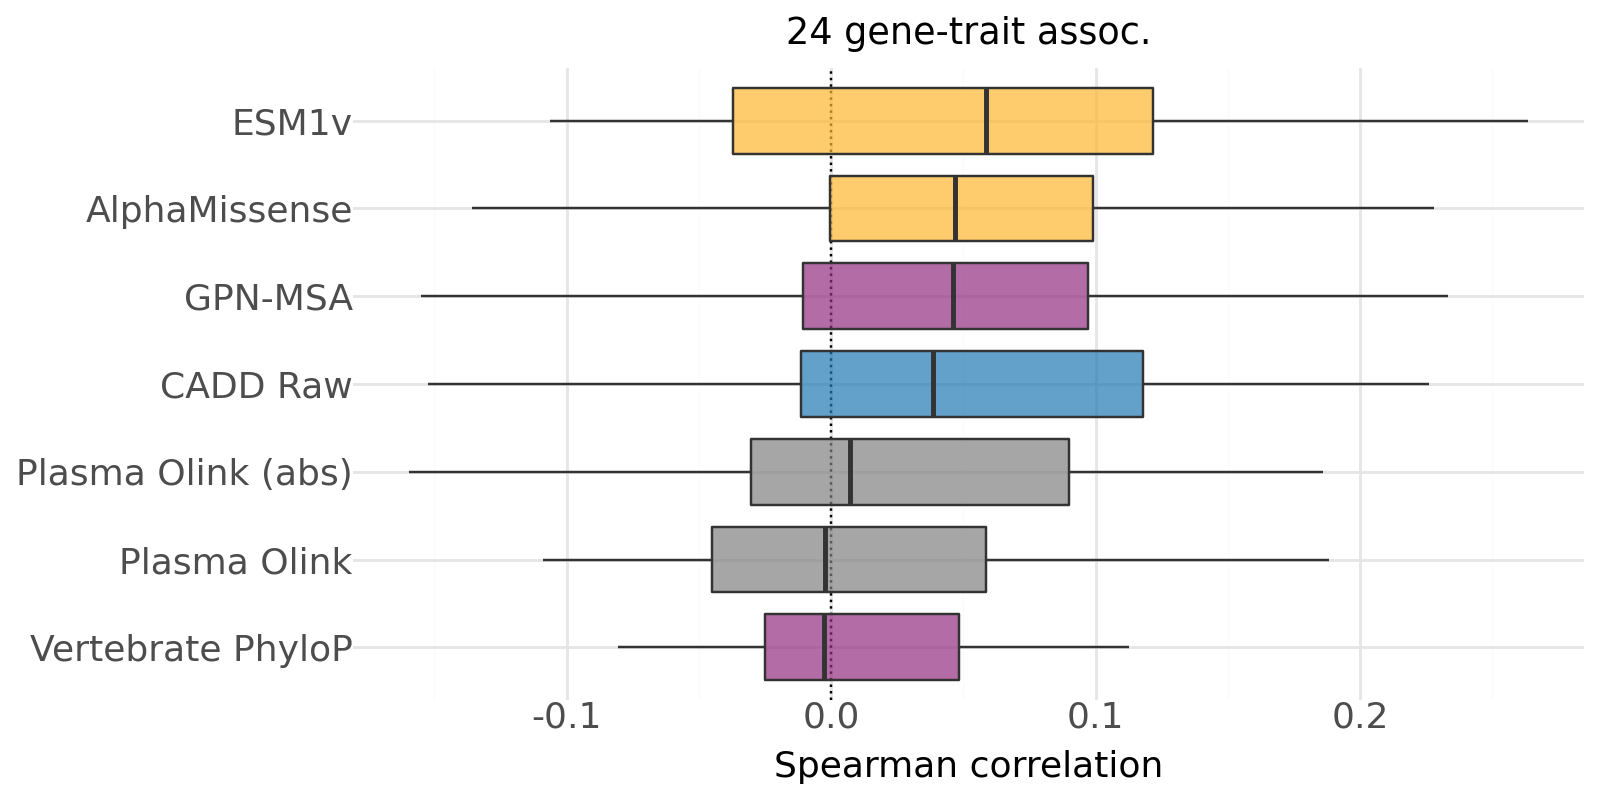

In [71]:
# Compute pairwise Wilcoxon tests between adjacent boxes and add asterisks
from scipy.stats import wilcoxon

plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Calculate medians and get ordering
corr_pl = (
    filt_corr_df
    .drop_nans()
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)

ordered_labels = (
    corr_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

# Get ordered annotations (not labels)
ordered_annos = (
    corr_pl
    .sort("median_corr_beta", descending=False)
    .select("annotation")
    .unique(maintain_order=True)
    .to_series()
)

corr_pl = corr_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))
color_dict = dict(corr_pl.select("annotation", "color").unique().iter_rows())

# Compute Wilcoxon tests for adjacent pairs (in plot order: bottom to top)
sig_pairs = []
for i in range(len(ordered_annos) - 1):
    anno_below = ordered_annos[i]
    anno_above = ordered_annos[i + 1]
    
    df_below = filt_corr_df.filter(pl.col("annotation") == anno_below).select(["region", "phenotype", "corr_beta"])
    df_above = filt_corr_df.filter(pl.col("annotation") == anno_above).select(["region", "phenotype", "corr_beta"])
    
    merged = df_below.join(df_above, on=["region", "phenotype"], how="inner", suffix="_above")
    
    if merged.height > 0:
        # One-sided test: is anno_above significantly GREATER than anno_below?
        stat, pval = wilcoxon(
            merged["corr_beta_above"].to_numpy(), 
            merged["corr_beta"].to_numpy(), 
            alternative="greater"
        )
        
        if pval < 0.05:
            sig_pairs.append({
                'anno_below': anno_below,
                'anno_above': anno_above,
                'y_pos': i + 0.5,  # Position between the two boxes
                'pval': pval
            })

# Create asterisk annotations
sig_df = pl.DataFrame(sig_pairs) if sig_pairs else None

# Plot with significance asterisks
plot = (
    ggplot(corr_pl, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{corr_pl[['region', 'phenotype']].unique().shape[0]} gene-trait assoc."
    )
    + coord_flip()
    + theme(
        figure_size=(8, corr_pl['annotation'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

# Add asterisks for significant adjacent pairs
if sig_df is not None and sig_df.height > 0:
    # Get max x value for asterisk placement
    max_x = corr_pl[plotting_col].max() * 1.05
    
    sig_annot = sig_df.with_columns(
        x = pl.lit(max_x),
        label_text = pl.when(pl.col('pval') < 0.001).then(pl.lit('***'))
                      .when(pl.col('pval') < 0.01).then(pl.lit('**'))
                      .when(pl.col('pval') < 0.05).then(pl.lit('*'))
                      .otherwise(pl.lit(''))
    )
    
    plot = plot + geom_text(
        sig_annot, 
        aes(x='x', y='y_pos', label='label_text'),
        size=16,
        color='black',
        ha='left'
    )
    
    print(f"Found {sig_df.height} significant adjacent pairs:")
    for row in sig_df.iter_rows(named=True):
        print(f"  {row['anno_above']} > {row['anno_below']} (p={row['pval']:.4f})")
else:
    print("No significant adjacent pairs found")

plot

## Find gene-trait pairs where olink_score_abs is the top annotation by corr_beta (ties included)

In [72]:
(
    corr_pl
    .filter(
        (pl.col('annotation')=='olink_mean_pheno_abs') &
        (pl.col('corr_beta')>0)
    )
)

region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations,median_corr_beta
str,str,str,u64,f64,str,enum,i8,f64,f64,f64,f64,f64,f64,u64,f64
"""ENSG00000169174""","""apolipoprotein_b_int""","""olink_mean_pheno_abs""",115,-0.18589,"""gray""","""Plasma Olink (abs)""",1,5.5832e-33,-0.193888,0.193888,-1.0,0.18589,0.958751,7,0.007265
"""ENSG00000119681""","""standing_height_int""","""olink_mean_pheno_abs""",243,0.163748,"""gray""","""Plasma Olink (abs)""",1,2.2425e-7,0.109201,0.109201,1.0,0.163748,1.499505,7,0.007265
"""ENSG00000180448""","""lymphocyte_count_int""","""olink_mean_pheno_abs""",153,-0.074458,"""gray""","""Plasma Olink (abs)""",1,0.000011,-0.109018,0.109018,-1.0,0.074458,0.682985,7,0.007265
"""ENSG00000108821""","""trunk_fatfree_mass_int""","""olink_mean_pheno_abs""",131,-0.013345,"""gray""","""Plasma Olink (abs)""",1,0.001302,-0.097994,0.097994,-1.0,0.013345,0.136186,7,0.007265
"""ENSG00000005844""","""lymphocyte_count_int""","""olink_mean_pheno_abs""",115,0.099491,"""gray""","""Plasma Olink (abs)""",1,0.00008,0.096474,0.096474,1.0,0.099491,1.031275,7,0.007265
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000171105""","""apolipoprotein_b_int""","""olink_mean_pheno_abs""",113,-0.001185,"""gray""","""Plasma Olink (abs)""",1,0.007933,-0.065906,0.065906,-1.0,0.001185,0.017983,7,0.007265
"""ENSG00000066056""","""lymphocyte_count_int""","""olink_mean_pheno_abs""",157,0.027738,"""gray""","""Plasma Olink (abs)""",1,0.021058,0.062014,0.062014,1.0,0.027738,0.447291,7,0.007265
"""ENSG00000106804""","""standing_height_int""","""olink_mean_pheno_abs""",157,-0.033809,"""gray""","""Plasma Olink (abs)""",1,0.027637,-0.046529,0.046529,-1.0,0.033809,0.726605,7,0.007265


In [73]:
phenotype_groups = ukb_phenotypes = {
    "Anthropometric": [
        "standing_height_int",
        "sitting_height_int",
        "seated_height_int",
        "weight_int",
        "body_mass_index_bmi_int",
        "waist_circumference_int",
        "hip_circumference_int",
        "body_fat_percentage_int",
        "whole_body_water_mass_int",
        "basal_metabolic_rate_int",
        "weight_impedance_int",
        "arm_fat_percentage_left_int",
        "arm_fat_percentage_right_int",
        "arm_fatfree_mass_left_int",
        "arm_fatfree_mass_right_int",
        "arm_predicted_mass_right_int",
        "leg_fat_percentage_left_int",
        "leg_fat_percentage_right_int",
        "leg_fat_mass_left_int",
        "leg_fat_mass_right_int",
        "leg_fatfree_mass_left_int",
        "leg_fatfree_mass_right_int",
        "leg_predicted_mass_left_int",
        "leg_predicted_mass_right_int",
        "trunk_fat_percentage_int",
        "trunk_fat_mass_int",
        "trunk_fatfree_mass_int",
        "trunk_predicted_mass_int",
        "heel_bone_mineral_density_bmd_left_int",
        "heel_bone_mineral_density_bmd_right_int",
        "heel_bone_mineral_density_bmd_tscore_automated_int",
        "heel_bone_mineral_density_bmd_tscore_automated_left_int",
        "heel_bone_mineral_density_bmd_tscore_automated_right_int",
        "forced_vital_capacity_fvc_int",
        "forced_vital_capacity_fvc_best_measure_int",
        "forced_expiratory_volume_in_1second_fev1_int",
        "forced_expiratory_volume_in_1second_fev1_best_measure_int",
        "forced_expiratory_volume_in_1second_fev1_predicted_int",
        "forced_expiratory_volume_in_1second_fev1_predicted_percentage_int",
        "peak_expiratory_flow_pef_int",
        "pulse_rate_int",
        "pulse_rate_automated_reading_int",
        "systolic_blood_pressure_automated_reading_int",
        "diastolic_blood_pressure_automated_reading_int",
        "stroke_volume_during_pwa_int",
        "position_of_pulse_wave_notch_int",
        "hand_grip_strength_left_int",
        "hand_grip_strength_right_int"
    ],
    "Blood Biochemistry": [
        "cholesterol_int",
        "hdl_cholesterol_int",
        "ldl_direct_int",
        "triglycerides_int",
        "apolipoprotein_a_int",
        "apolipoprotein_b_int",
        "lipoprotein_a_int",
        "albumin_int",
        "total_protein_int",
        "alkaline_phosphatase_int",
        "alanine_aminotransferase_int",
        "aspartate_aminotransferase_int",
        "gamma_glutamyltransferase_int",
        "total_bilirubin_int",
        "direct_bilirubin_int",
        "creatinine_int",
        "cystatin_c_int",
        "urea_int",
        "urate_int",
        "calcium_int",
        "phosphate_int",
        "glucose_int",
        "glycated_haemoglobin_hba1c_int",
        "igf1_int",
        "shbg_int",
        "testosterone_int",
        "vitamin_d_int",
        "creactive_protein_int"
    ],
    "Haematology": [
        "white_blood_cell_leukocyte_count_int",
        "red_blood_cell_erythrocyte_count_int",
        "haemoglobin_concentration_int",
        "haematocrit_percentage_int",
        "mean_corpuscular_volume_int",
        "mean_corpuscular_haemoglobin_int",
        "mean_corpuscular_haemoglobin_concentration_int",
        "red_blood_cell_erythrocyte_distribution_width_int",
        "platelet_count_int",
        "platelet_crit_int",
        "mean_platelet_thrombocyte_volume_int",
        "platelet_distribution_width_int",
        "neutrophill_count_int",
        "lymphocyte_count_int",
        "monocyte_count_int",
        "eosinophill_count_int",
        "basophill_count_int",
        "neutrophill_percentage_int",
        "lymphocyte_percentage_int",
        "monocyte_percentage_int",
        "eosinophill_percentage_int",
        "basophill_percentage_int",
        "reticulocyte_percentage_int",
        "reticulocyte_count_int",
        "mean_reticulocyte_volume_int",
        "mean_sphered_cell_volume_int",
        "immature_reticulocyte_fraction_int",
        "high_light_scatter_reticulocyte_percentage_int",
        "high_light_scatter_reticulocyte_count_int"
    ],
    "Urine Biochemistry": [
        "microalbumin_in_urine_int",
        "creatinine_enzymatic_in_urine_int"
    ],
    "Other": [
        "fluid_intelligence_score_int",
        "mean_time_to_correctly_identify_matches_int",
        "townsend_deprivation_index_at_recruitment_int",
        "age_at_hysterectomy_int",
        "fathers_age_at_death_int",
        "mothers_age_at_death_int",
        "age_started_wearing_glasses_or_contact_lenses_int"
    ]
}

# Reverse lookup helper (phenotype -> group)
pheno_to_group = {ph:grp for grp, phs in phenotype_groups.items() for ph in phs}


pheno_grouping_df = pl.DataFrame({
    'phenotype': [pheno for group in phenotype_groups for pheno in phenotype_groups[group]],
    'phenotype_group': [group for group in phenotype_groups for pheno in phenotype_groups[group]]
})

pheno_grouping_df

phenotype,phenotype_group
str,str
"""standing_height_int""","""Anthropometric"""
"""sitting_height_int""","""Anthropometric"""
"""seated_height_int""","""Anthropometric"""
"""weight_int""","""Anthropometric"""
"""body_mass_index_bmi_int""","""Anthropometric"""
…,…
"""townsend_deprivation_index_at_…","""Other"""
"""age_at_hysterectomy_int""","""Other"""
"""fathers_age_at_death_int""","""Other"""


In [76]:
corr_pl_pheno_grps = (
    corr_pl
    .filter(pl.col('annotation')=='olink_mean_pheno_abs')
    .join(pheno_grouping_df, on='phenotype', how='left')
)

corr_pl_pheno_grps

region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations,median_corr_beta,phenotype_group
str,str,str,u64,f64,str,enum,i8,f64,f64,f64,f64,f64,f64,u64,f64,str
"""ENSG00000145703""","""mean_platelet_thrombocyte_volu…","""olink_mean_pheno_abs""",148,-0.130621,"""gray""","""Plasma Olink (abs)""",1,2.3369e-43,0.230588,0.230588,1.0,-0.130621,-0.56647,7,0.007265,"""Haematology"""
"""ENSG00000169174""","""apolipoprotein_b_int""","""olink_mean_pheno_abs""",115,-0.18589,"""gray""","""Plasma Olink (abs)""",1,5.5832e-33,-0.193888,0.193888,-1.0,0.18589,0.958751,7,0.007265,"""Blood Biochemistry"""
"""ENSG00000111252""","""cholesterol_int""","""olink_mean_pheno_abs""",131,0.021299,"""gray""","""Plasma Olink (abs)""",1,0.015547,-0.168399,0.168399,-1.0,-0.021299,-0.126477,7,0.007265,"""Blood Biochemistry"""
"""ENSG00000165458""","""whole_body_water_mass_int""","""olink_mean_pheno_abs""",166,-0.03783,"""gray""","""Plasma Olink (abs)""",1,0.030338,0.127209,0.127209,1.0,-0.03783,-0.297382,7,0.007265,"""Anthropometric"""
"""ENSG00000119681""","""standing_height_int""","""olink_mean_pheno_abs""",243,0.163748,"""gray""","""Plasma Olink (abs)""",1,2.2425e-7,0.109201,0.109201,1.0,0.163748,1.499505,7,0.007265,"""Anthropometric"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000163359""","""arm_predicted_mass_right_int""","""olink_mean_pheno_abs""",423,0.027453,"""gray""","""Plasma Olink (abs)""",1,0.019299,-0.056426,0.056426,-1.0,-0.027453,-0.486536,7,0.007265,"""Anthropometric"""
"""ENSG00000099331""","""mean_platelet_thrombocyte_volu…","""olink_mean_pheno_abs""",258,-0.006519,"""gray""","""Plasma Olink (abs)""",1,0.014032,0.048816,0.048816,1.0,-0.006519,-0.133552,7,0.007265,"""Haematology"""
"""ENSG00000106804""","""standing_height_int""","""olink_mean_pheno_abs""",157,-0.033809,"""gray""","""Plasma Olink (abs)""",1,0.027637,-0.046529,0.046529,-1.0,0.033809,0.726605,7,0.007265,"""Anthropometric"""


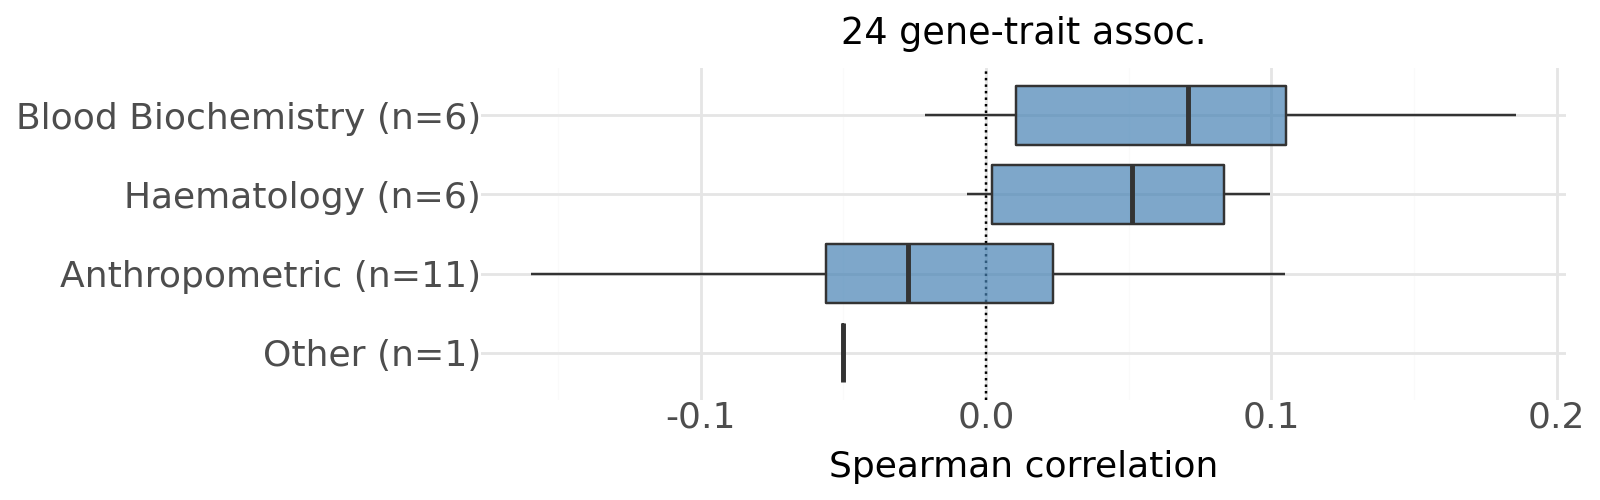

In [77]:
# Calculate median and count per phenotype group using window functions
corr_pl_pheno_grps_with_stats = (
    corr_pl_pheno_grps
    .with_columns([
        pl.col(plotting_col).median().over("phenotype_group").alias("median_corr"),
        pl.len().over("phenotype_group").alias("n")
    ])
)

# Get ordered groups with labels
ordered_groups = (
    corr_pl_pheno_grps_with_stats
    .select(["phenotype_group", "median_corr", "n"])
    .unique()
    .sort("median_corr", descending=False)
    .with_columns(
        label_with_n = pl.concat_str([
            pl.col("phenotype_group"),
            pl.lit(" (n="),
            pl.col("n").cast(pl.Utf8),
            pl.lit(")")
        ])
    )
)

ordered_group_labels = ordered_groups["label_with_n"].to_list()

# Add labels to plot data and apply enum ordering
plot_data = (
    corr_pl_pheno_grps_with_stats
    .join(ordered_groups.select(["phenotype_group", "label_with_n"]), on="phenotype_group")
    .with_columns(pl.col("label_with_n").cast(pl.Enum(ordered_group_labels)))
)

(
    ggplot(plot_data, aes(x="label_with_n", y=plotting_col))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, fill='steelblue', outlier_shape=None)
    + theme_minimal()
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{corr_pl_pheno_grps[['region', 'phenotype']].unique().shape[0]} gene-trait assoc."
    )
    + coord_flip()
    + theme(
        figure_size=(8, len(ordered_group_labels)/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)